# Kaggle competition for Assignment 1

### <span style="color:#0b486b"> II.0 Running on Google Colab</span> <span style="color:red"></span>
You will need to download relevant files to run this notebook on Google Colab.

Backup link for the training set.

In [ ]:
!gdown --fuzzy https://drive.google.com/file/d/1NlGTb-aM9FLQMlk5USBLRSBaP0dU3fip/view?usp=sharing

Downloading...
From (original): https://drive.google.com/uc?id=1NlGTb-aM9FLQMlk5USBLRSBaP0dU3fip
From (redirected): https://drive.google.com/uc?id=1NlGTb-aM9FLQMlk5USBLRSBaP0dU3fip&confirm=t&uuid=c3db1d94-6c08-4604-a636-4d008b1c0609
To: /content/Animals_Dataset.zip
100% 643M/643M [00:19<00:00, 32.6MB/s]


In [ ]:
!unzip -q Animals_Dataset.zip

In [ ]:
# !pip uninstall -y torch torchvision torchaudio
# !pip install torch torchvision torchaudio

In [ ]:
import os
import requests
import tarfile
import time
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torchvision.models as models
import torch.nn as nn
import torch

import PIL.Image
import pathlib
from torchsummary import summary
import matplotlib.pyplot as plt

%matplotlib inline
import numpy as np

# check if CUDA is available
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CUDA is available!  Training on GPU ...


In [ ]:
import random
def seed_all(seed=1029):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
seed_all(1029)

## Data Preprocess

In [ ]:
data_dir = "./FIT5215_Dataset"

# We resize the images to [3,64,64]
transform = transforms.Compose([transforms.Resize((192,192)),  #resises the image so it can be perfect for our model.
                                      transforms.RandomHorizontalFlip(), # FLips the image w.r.t horizontal axis
                                      # transforms.RandomRotation(4),     #Rotates the image to a specified angel
                                      # transforms.RandomAffine(0, shear=10, scale=(0.8,1.2)), #Performs actions like zooms, change shear angles.
                                      transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Set the color params
                                      transforms.ToTensor(), # convert the image to tensor so that it can work with torch
                                      transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # Normalize the images, each R,G,B value is normalized with mean=0.5 and std=0.5
                                      ])


# Load the dataset using torchvision.datasets.ImageFolder and apply transformations
dataset = datasets.ImageFolder(data_dir, transform=transform)

# Split the dataset into training and validation sets
train_size = int(0.95 * len(dataset))
valid_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, valid_size])

# Example of DataLoader creation for training and validation
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Number of instance in train_set: %s" % len(train_dataset))
print("Number of instance in val_set: %s" % len(val_dataset))

Number of instance in train_set: 8992
Number of instance in val_set: 474


In [ ]:
class_names = ['birds', 'bottles', 'breads', 'butterflies', 'cakes', 'cats', 'chickens', 'cows', 'dogs', 'ducks',
                  'elephants', 'fishes', 'handguns', 'horses', 'lions', 'lipsticks', 'seals', 'snakes', 'spiders', 'vases']

## Define Models

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def compute_loss(model, loss_fn, loader):
  loss = 0
  # Set model to eval mode for inference
  model.eval()
  with torch.no_grad():  # No need to track gradients for validation
    for (batchX, batchY) in loader:
      # Move data to the same device as the model
      batchX, batchY = batchX.to(device).type(torch.float32), batchY.to(device).type(torch.long)
      loss += loss_fn(model(batchX), batchY)
  # Set model back to train mode
  model.train()
  return float(loss)/len(loader)

In [ ]:
def compute_acc(model, loader):
    correct = 0
    totals = 0
    # Set model to eval mode for inference
    model.eval()
    for (batchX, batchY) in loader:
        # Move batchX and batchY to the same device as the model
        batchX, batchY = batchX.to(device).type(torch.float32), batchY.to(device)
        outputs = model(batchX)  # feed batch to the model
        totals += batchY.size(0)  # accumulate totals with the current batch size
        predicted = torch.argmax(outputs.data, 1)  # get the predicted class
        # Move batchY to the same device as predicted for comparison
        correct += (predicted == batchY).sum().item()
    return correct / totals

In [ ]:
def visualize(history):
    import pandas as pd
    import matplotlib.pyplot as plt

    his = history
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111)
    ln1 = ax.plot(his['train_loss'], 'r--',label='train_loss')
    ln2 = ax.plot(his['val_loss'], 'b-',label='val_loss')
    ax.set_ylabel('loss', color='blue')
    ax.tick_params(axis='y', colors="blue")

    lns = ln1 + ln2
    labels = [l.get_label() for l in lns]
    ax.legend(lns, labels, loc=7)
    plt.grid(True)
    plt.show()

Here are some example CNNs for the demonstration purpose. You should use your own developed network for the competition.

In [ ]:
!pip install timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 48.0 MB/s eta 0:00:00


In [ ]:
import timm
import torch
from torch import nn

# Load the pretrained Swin Transformer Large model
# model = timm.create_model('swin_large_patch4_window7_224', pretrained=True)
model = timm.create_model('swinv2_large_window12_192_22k', pretrained=True)
# model = timm.create_model('vit_large_patch16_224', pretrained=True)
# model = models.convnext_tiny(pretrained=True)
print(model)


/usr/local/lib/python3.10/dist-packages/timm/models/_factory.py:117: UserWarning: Mapping deprecated model name swinv2_large_window12_192_22k to current swinv2_large_window12_192.ms_in22k.
  model = create_fn(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/917M [00:00<?, ?B/s]

SwinTransformerV2(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerV2Stage(
      (downsample): Identity()
      (blocks): ModuleList(
        (0): SwinTransformerV2Block(
          (attn): WindowAttention(
            (cpb_mlp): Sequential(
              (0): Linear(in_features=2, out_features=512, bias=True)
              (1): ReLU(inplace=True)
              (2): Linear(in_features=512, out_features=6, bias=False)
            )
            (qkv): Linear(in_features=192, out_features=576, bias=False)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=192, out_features=192, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
          (drop_path1): 

## Training the Model

### Model Selection

In [ ]:

for param in model.parameters():
    param.requires_grad = False

# Modify the last fully connected layer for Flower102
num_features = model.head.fc.in_features
model.head.fc = nn.Linear(num_features, 20)
model = model.to(device)
print(model)

SwinTransformerV2(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerV2Stage(
      (downsample): Identity()
      (blocks): ModuleList(
        (0): SwinTransformerV2Block(
          (attn): WindowAttention(
            (cpb_mlp): Sequential(
              (0): Linear(in_features=2, out_features=512, bias=True)
              (1): ReLU(inplace=True)
              (2): Linear(in_features=512, out_features=6, bias=False)
            )
            (qkv): Linear(in_features=192, out_features=576, bias=False)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=192, out_features=192, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
          (drop_path1): 

In [ ]:
#Your code here
# loss computation base on OVA
def compute_ova_loss(logits, labels):
    """
    Compute the One-Versus-All (OVA) loss for a batch of logits and labels.

    Args:
        logits (torch.Tensor): Logits output from the model, shape (batch_size, num_classes).
        labels (torch.Tensor): Ground truth labels, shape (batch_size).

    Returns:
        torch.Tensor: Computed OVA loss.
    """

    # Ensure labels are of type long (required for indexing)
    labels = labels.long()

    # Apply sigmoid to logits to get probabilities
    probabilities = torch.sigmoid(logits)

    # Compute the loss for the true class
    true_label_prob = probabilities[range(len(labels)), labels] # choose the ground-truth label
    true_label_loss = -torch.log(true_label_prob + 1e-7) # avoid log0

    # Compute the loss for the other classes
    other_labels_loss = -torch.sum(torch.log(1 - probabilities + 1e-7), dim=1)

    # Combine the losses
    total_loss = torch.mean(true_label_loss + other_labels_loss)

    return total_loss

In [ ]:
#Your code here
import random
# mixup data with train dataset
def mixup_data(x, y, alpha=1.0, use_cuda=True):
    '''Compute the mixup data. Return mixed inputs, pairs of targets, and lambda
    Args:
        x: tensor, image a
        y: tensor, image b
        alpha: float, alpha parameter for Beta distribution
        use_cuda: whether to use GPU or CPU
    Returns:
        mixed_x: tensor, mixed x and y
        y_a: one-hot label for image a
        y_b: one-hot label for image b
        lambda: float, lambda parameter for mixup'''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    if use_cuda:
        index = torch.randperm(batch_size).cuda()
    else:
        index = torch.randperm(batch_size)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

# loss function for mix-up, refer to slide 48, week5
def mixup_criterion(loss_fn, pred, y_a, y_b, lam, mixup_ratio=0.5, smoothing=0.1, num_classes=20):
    # mixup_size = int(pred.size(0) * mixup_ratio)
    #
    # loss = 0
    # if mixup_size > 0:
    #     loss += lam * compute_ova_loss(pred[:mixup_size], y_a[:mixup_size]) + \
    #             (1 - lam) * compute_ova_loss(pred[:mixup_size], y_b[:mixup_size])
    # if mixup_size < pred.size(0):
    #     loss += loss_fn(pred[mixup_size:], y_a[mixup_size:])

    loss = lam * compute_ova_loss(pred, y_a) + (1 - lam) * compute_ova_loss(pred, y_b)
    return loss


#### <span style="color:#0b486b">4. Declaring the Loss, Optimizer, learning rate and Training the Model </span>

In [ ]:
def top_k_accuracy(output, target, k=5):
    batch_size = target.size(0)
    _, pred = output.topk(k, 1, True, True)  # Get top-k predictions
    pred = pred.t()  # Transpose predictions for comparison
    correct = pred.eq(target.reshape(1, -1).expand_as(pred))  # Compare predictions with target
    correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)  # Calculate correct top-k
    return correct_k.mul_(1.0 / batch_size).item()  # Calculate top-k accuracy

class BaseTrainer:
    def __init__(self, model, criterion, optimizer, train_loader, val_loader):
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.stop_training = False

    def fit(self, num_epochs):
        self.num_batches = len(self.train_loader)
        history = dict() #declare the dictionary history with the keys:val_loss, val_acc, train_loss, train_acc
        history['val_loss'] = list()
        history['val_acc'] = list()
        history['train_loss'] = list()
        history['train_acc'] = list()
        for epoch in range(num_epochs):
            if self.stop_training:
                break
            print(f'Epoch {epoch + 1}/{num_epochs}')
            start_time = time.time()
            train_loss, train_accuracy = self.train_one_epoch()
            val_loss, top1_acc, top5_acc = self.validate_one_epoch()

            history['val_loss'].append(val_loss)
            history['val_acc'].append(top1_acc)
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_accuracy)
            print(
                f' train_loss: {train_loss:.4f} - train_accuracy: {train_accuracy:.4f} - val_loss: {val_loss:.4f} - top1_acc: {top1_acc:.4f} - top5_acc: {top5_acc:.4f}'
            )
            self.on_epoch_end({'epoch': epoch, 'train_loss': train_loss, 'train_accuracy': train_accuracy, 'val_loss': val_loss, 'val_accuracy': top1_acc, 'top5_acc': top5_acc})
        return history
    def train_one_epoch(self):
        self.model.train()
        running_loss, correct, total = 0.0, 0, 0

        for i, data in enumerate(self.train_loader):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            self.optimizer.zero_grad()

            # apply mixup for data
            X, y_a, y_b, lam = mixup_data(inputs, labels, alpha=1.0, use_cuda=train_on_gpu)

            # Forward pass
            mixup_outputs = model(X.type(torch.float32)) # X is already on the correct device

            # apply loss for mixup data
            mixup_loss = mixup_criterion(self.criterion, mixup_outputs, y_a, y_b, lam)

            mixup_loss.backward()
            self.optimizer.step()

            outputs = self.model(inputs)
            loss = self.criterion(outputs, labels)


            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = correct / total
        train_loss = running_loss / self.num_batches
        return train_loss, train_accuracy

    def validate_one_epoch(self):
        self.model.eval()
        val_loss, correct, total_top1_acc, total_top5_acc, total = 0.0, 0, 0.0, 0.0, 0
        with torch.no_grad():
            for data in self.val_loader:
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)


                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)

                # # apply mixup for data
                # X, y_a, y_b, lam = mixup_data(inputs, labels, alpha=1.0, use_cuda=train_on_gpu)

                # # Forward pass
                # outputs = model(X.type(torch.float32)) # X is already on the correct device

                # # apply loss for mixup data
                # loss = mixup_criterion(self.criterion, outputs, y_a, y_b, lam)


                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                correct += (predicted == labels).sum().item()

                top1_acc = top_k_accuracy(outputs, labels, k=1)
                top5_acc = top_k_accuracy(outputs, labels, k=5)

                total_top1_acc += top1_acc * inputs.size(0)  # Custom evaluation metric
                total_top5_acc += top5_acc * inputs.size(0)  # Custom evaluation metric
                total += labels.size(0)

        val_loss /= len(self.val_loader)
        top1_acc = total_top1_acc / total
        top5_acc = total_top5_acc / total
        return val_loss, top1_acc, top5_acc

    def on_epoch_end(self, params):
        pass

Epoch 1/10
 train_loss: 0.4476 - train_accuracy: 0.9718 - val_loss: 0.2285 - top1_acc: 0.9979 - top5_acc: 0.9979
Epoch 2/10
 train_loss: 0.2029 - train_accuracy: 0.9974 - val_loss: 0.1897 - top1_acc: 0.9979 - top5_acc: 0.9979
Epoch 3/10
 train_loss: 0.1790 - train_accuracy: 0.9980 - val_loss: 0.1611 - top1_acc: 0.9979 - top5_acc: 0.9979
Epoch 4/10
 train_loss: 0.1685 - train_accuracy: 0.9982 - val_loss: 0.1667 - top1_acc: 0.9979 - top5_acc: 0.9979
Epoch 5/10
 train_loss: 0.1572 - train_accuracy: 0.9987 - val_loss: 0.1579 - top1_acc: 0.9979 - top5_acc: 0.9979
Epoch 6/10
 train_loss: 0.1512 - train_accuracy: 0.9989 - val_loss: 0.1548 - top1_acc: 0.9979 - top5_acc: 0.9979
Epoch 7/10
 train_loss: 0.1439 - train_accuracy: 0.9992 - val_loss: 0.1472 - top1_acc: 0.9979 - top5_acc: 0.9979
Epoch 8/10
 train_loss: 0.1369 - train_accuracy: 0.9991 - val_loss: 0.1521 - top1_acc: 0.9979 - top5_acc: 0.9979
Epoch 9/10
 train_loss: 0.1401 - train_accuracy: 0.9990 - val_loss: 0.1458 - top1_acc: 0.9979 - 

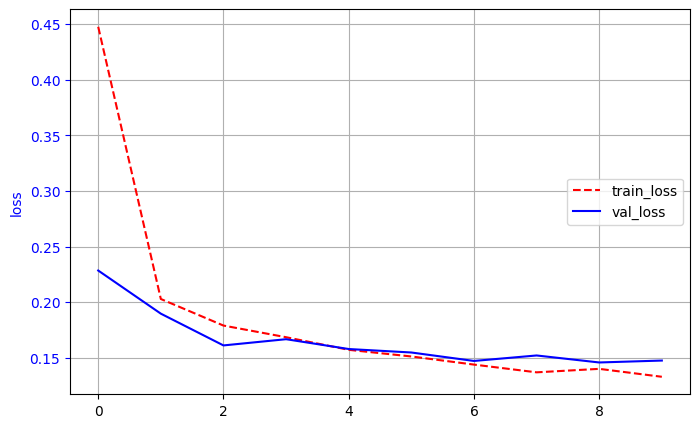

Model saved successfully!


In [ ]:
from torch import optim
optim_dict = {"Adam":optim.Adam, "Adadelta":optim.Adadelta, "Adagrad":optim.Adagrad,
              "Adamax":optim.Adamax, "AdamW": optim.AdamW, "ASGD":optim.ASGD,
              "NAdam":optim.NAdam, "RMSprop":optim.RMSprop, "RAdam":optim.RAdam,
              "Rprop": optim.Rprop, "SGD":optim.SGD}

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
# optimizer = optim_dict["AdamW"](model.parameters(), lr=1e-3)
trainer = BaseTrainer(model, criterion, optimizer, train_loader, val_loader)
history = trainer.fit(num_epochs=10)
visualize(history)

# Save the trained model
torch.save(model, 'freeze_model.pth')

print("Model saved successfully!")

<ipython-input-19-354194f35d78>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('freeze_model.pth')


Epoch 1/10
 train_loss: 0.1347 - train_accuracy: 0.9973 - val_loss: 0.1064 - top1_acc: 0.9958 - top5_acc: 0.9979
Epoch 2/10
 train_loss: 0.1489 - train_accuracy: 0.9900 - val_loss: 0.1087 - top1_acc: 0.9958 - top5_acc: 0.9979
Epoch 3/10
 train_loss: 0.0758 - train_accuracy: 0.9987 - val_loss: 0.1104 - top1_acc: 0.9937 - top5_acc: 0.9958
Epoch 4/10
 train_loss: 0.0932 - train_accuracy: 0.9956 - val_loss: 0.1053 - top1_acc: 0.9979 - top5_acc: 1.0000
Epoch 5/10
 train_loss: 0.0690 - train_accuracy: 0.9981 - val_loss: 0.0574 - top1_acc: 0.9979 - top5_acc: 0.9979
Epoch 6/10
 train_loss: 0.0604 - train_accuracy: 0.9986 - val_loss: 0.0649 - top1_acc: 0.9937 - top5_acc: 0.9979
Epoch 7/10
 train_loss: 0.0600 - train_accuracy: 0.9981 - val_loss: 0.0715 - top1_acc: 0.9958 - top5_acc: 0.9979
Epoch 8/10
 train_loss: 0.0472 - train_accuracy: 0.9991 - val_loss: 0.0679 - top1_acc: 0.9958 - top5_acc: 1.0000
Epoch 9/10
 train_loss: 0.0505 - train_accuracy: 0.9992 - val_loss: 0.0569 - top1_acc: 0.9958 - 

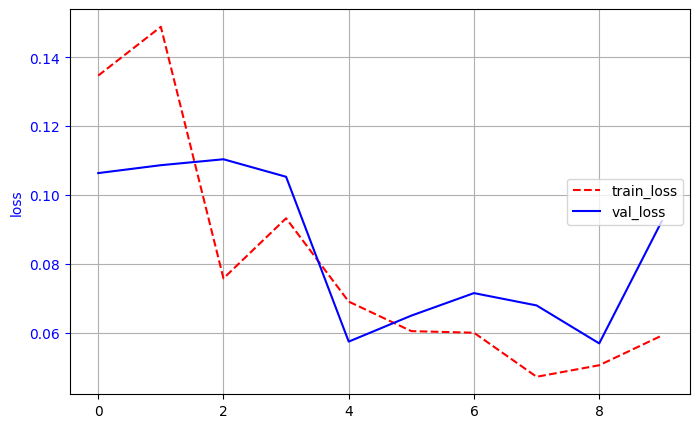

Model saved successfully!


In [ ]:
model = torch.load('freeze_model.pth')
model = model.to(device)
for param in model.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
# optimizer = optim_dict["AdamW"](model.parameters(), lr=1e-3)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4, momentum=0.9)
trainer = BaseTrainer(model, criterion, optimizer, train_loader, val_loader)
history= trainer.fit(num_epochs=10)
visualize(history)
torch.save(model, 'unfreeze_model.pth')

print("Model saved successfully!")

#### <span style="color:#0b486b">5. Visualizing the Performance and Loss Objective Function </span>

There are four keys in the history dictionary: `train_loss` and `val_loss` measure the loss on the training set and the validation set, respectively, while `train_acc` and `val_acc` measure the accuracy on the training set and the validation set.  
The following figure visualize all four metrics with two y-axes, losses (blue lines, in descending) and accuracies (red lines, in asending)


# Evaluate model on the testing set, get the csv file and upload to kaggle website.

In [ ]:
!gdown --fuzzy https://drive.google.com/file/d/1HuVqfbzL2g5an8e_1_NwrQWoKEzEvnZ8/view?usp=sharing

Downloading...
From (original): https://drive.google.com/uc?id=1HuVqfbzL2g5an8e_1_NwrQWoKEzEvnZ8
From (redirected): https://drive.google.com/uc?id=1HuVqfbzL2g5an8e_1_NwrQWoKEzEvnZ8&confirm=t&uuid=fe69c6ed-d208-4eb3-a327-88af47dd06b0
To: /content/test_set.zip
100% 28.9M/28.9M [00:00<00:00, 81.2MB/s]


In [ ]:
!unzip -q test_set.zip

In [ ]:
test_data_dir = "./test_set"

# We resize the images to [3,64,64]
transform = transforms.Compose([transforms.Resize((192,192)),  #resises the image so it can be perfect for our model.
                                      #transforms.RandomHorizontalFlip(), # FLips the image w.r.t horizontal axis
                                      #transforms.RandomRotation(4),     #Rotates the image to a specified angel
                                      #transforms.RandomAffine(0, shear=10, scale=(0.8,1.2)), #Performs actions like zooms, change shear angles.
                                      #transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Set the color params
                                      transforms.ToTensor(), # convert the image to tensor so that it can work with torch
                                      transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # Normalize the images, each R,G,B value is normalized with mean=0.5 and std=0.5
                                      ])


# Load the dataset using torchvision.datasets.ImageFolder and apply transformations
testset = datasets.ImageFolder(test_data_dir, transform=transform)

print("Number of instance in test_set: %s" % len(testset))

test_loader = DataLoader(testset, batch_size=64, shuffle=False)


Number of instance in test_set: 16167


In [ ]:
import torch
import pandas as pd

def save_prediction_to_csv(model, loader, device, output_file="submission.csv"):
    model.eval()
    predictions = []
    image_ids = []
    df = {
    "ID": [],
    "Label": []
    }
    total = 0
    with torch.no_grad():
        for i, (batchX, batchY) in enumerate(loader):
            batchX, batchY = batchX.to(device), batchY.to(device)
            outputs = model(batchX.float())  # Convert to float32 and feed batch to the model
            predicted = torch.argmax(outputs, dim=1)  # Get the predicted class
            total += predicted.size(0)
            for ids, pred in enumerate(predicted):
                label = class_names[pred.to(device).item()]
                df["ID"].append(i*500+ids)
                df["Label"].append(label)
    df["ID"] = [i for i in range(total)]
    # Create a DataFrame
    df = pd.DataFrame(df)
    # Save to CSV
    df.to_csv(output_file, index=False)

In [ ]:
save_prediction_to_csv(model, test_loader, device)

# Upload result to kaggle competition

## Regsiter Kaggle account using your private gmail
## Join the competition
## Upload the submission.csv file to the kaggle website to get your results